# OH⁻ vs OH• — System Comparison

Direct comparison of the charged hydroxide anion (OH⁻, `charged_singlet`) and the
neutral hydroxyl radical (OH•, `neutral_doublet`) in a 39-water simulation box.

| | Ionic (OH⁻) | Radical (OH•) |
|---|---|---|
| Notebook | `oh_analysis.ipynb` | `oh_rad_analysis.ipynb` |
| Charge / spin | −1 / singlet | 0 / doublet |
| Trajectory | `charged_singlet` | `neutral_doublet` |

> Both trajectories share the same box composition (39 H₂O + 1 HO, 119 atoms,
> 20 001 frames) and bond-detection parameters (`covalent_scale=0.8`,
> `atom_hop cutoff=1.25 Å, persistence=3`).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

from chempiler import ChempilerTrajectory, plot_rdf
from chempiler.state_engine import atom_hop, ligand_exchange

traj_ion = ChempilerTrajectory(
    '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.traj',
    mode='molecular', covalent_scale=0.8, # NOTE: The covalent scale is important to capture the O-H bond in the ion. To avoid seeing clusters of water molecules as bonded.
)
traj_ion.build(cache_file='tests/OH_cache.h5')
frames_ion = traj_ion.frames

traj_rad = ChempilerTrajectory(
    '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.traj',
    mode='molecular', covalent_scale=0.8, # NOTE: Using the same covalent scale for the radical for consistency.
)
traj_rad.build(cache_file='tests/OH_rad_cache.h5')
frames_rad = traj_rad.frames

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # Persistence of 3 means that the hop must be observed in at least 3 consecutive frames to be counted as a valid transition.
    # This is equivalent to 30 frames x 0.5 fs = 15 fs.
    result_ion = atom_hop(frames_ion, tracked='H', host='O', cutoff=1.25, persistence=3)
    result_rad = atom_hop(frames_rad, tracked='H', host='O', cutoff=1.25, persistence=3)

C  = {'ion': 'steelblue', 'rad': 'tomato'}
LS = {'ion': '-',         'rad': '--'}

n_ion = result_ion['n_transitions']
n_rad = result_rad['n_transitions']
print(f'Ionic   : {len(frames_ion)} frames | {n_ion} hops')
print(f'Radical : {len(frames_rad)} frames | {n_rad} hops')

---
## 1 — Species composition & OH lifetime

In [2]:
sum_ion = traj_ion.summary()
sum_rad = traj_rad.summary()
all_forms = sorted(set(sum_ion) | set(sum_rad))

header = '{:<10} {:>18} {:>18}'.format('Formula', 'OH⁻ (avg/frame)', 'OH• (avg/frame)')
print(header)
print('-' * len(header))
for f in all_forms:
    a = sum_ion.get(f, 0) / len(frames_ion)
    b = sum_rad.get(f, 0) / len(frames_rad)
    print('  {:<8} {:>18.4f} {:>18.4f}'.format(f, a, b))

print()

ho_segs_ion = traj_ion.lifetime_segments('HO')
ho_segs_rad = traj_rad.lifetime_segments('HO')
seg_lens_ion = np.array([e - s for s, e in ho_segs_ion])
seg_lens_rad = np.array([e - s for s, e in ho_segs_rad])

for label, segs, lens, frames in [
    ('OH⁻', ho_segs_ion, seg_lens_ion, frames_ion),
    ('OH•', ho_segs_rad, seg_lens_rad, frames_rad),
]:
    cov = 100 * lens.sum() / len(frames)
    print(f'{label}: {len(segs)} segment(s)  |  {cov:.1f}% coverage  |  '
          f'median {np.median(lens):.0f} fr  |  max {lens.max()} fr')

Formula       OH⁻ (avg/frame)    OH• (avg/frame)
------------------------------------------------
  H2O                 38.8938            38.9985
  H3O2                 0.1042             0.0000
  H4O2                 0.0005             0.0007
  H5O3                 0.0004             0.0000
  HO                   0.8953             1.0000

OH⁻: 983 segment(s)  |  89.5% coverage  |  median 7 fr  |  max 381 fr
OH•: 1 segment(s)  |  100.0% coverage  |  median 20001 fr  |  max 20001 fr


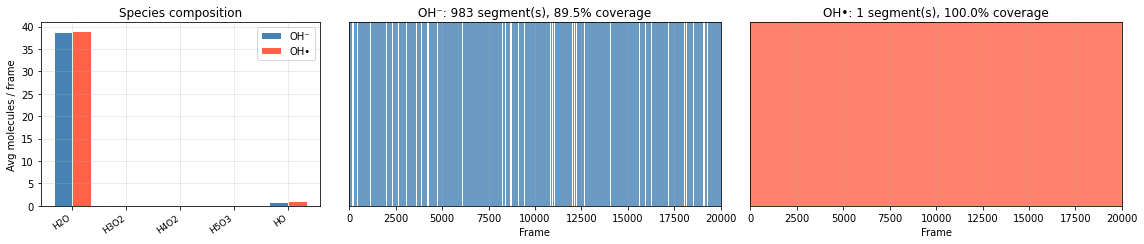

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5),
                         gridspec_kw={'width_ratios': [1.5, 2, 2]})

# Left: species bar chart
x = np.arange(len(all_forms))
w = 0.35
v_ion = [sum_ion.get(f, 0) / len(frames_ion) for f in all_forms]
v_rad = [sum_rad.get(f, 0) / len(frames_rad) for f in all_forms]
axes[0].bar(x - w/2, v_ion, w, color=C['ion'], label='OH⁻', edgecolor='white')
axes[0].bar(x + w/2, v_rad, w, color=C['rad'], label='OH•', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_forms, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Avg molecules / frame')
axes[0].set_title('Species composition')
axes[0].legend()

# Centre + Right: occurrence strips
for ax, segs, frames, key, lbl in [
    (axes[1], ho_segs_ion, frames_ion, 'ion', 'OH⁻'),
    (axes[2], ho_segs_rad, frames_rad, 'rad', 'OH•'),
]:
    for s, e in segs:
        ax.axvspan(s, e, color=C[key], alpha=0.8, lw=0)
    ax.set_xlim(0, len(frames))
    ax.set_yticks([])
    ax.set_xlabel('Frame')
    cov = 100 * sum(e - s for s, e in segs) / len(frames)
    ax.set_title(f'{lbl}: {len(segs)} segment(s), {cov:.1f}% coverage')

plt.tight_layout()
plt.show()

**Interpretation:**
The two systems differ fundamentally in OH occupancy. The radical (OH•) occupies a
single unbroken segment spanning the full trajectory (100% coverage) — it never
transfers its hydrogen. The ionic hydroxide (OH⁻) shows 983 segments with 89.5%
coverage, with frequent brief proton-exchange events creating temporary gaps
(median 7 frames per segment, max 381 frames).

The species composition reflects this: H₃O₂ and H₅O₃ transient clusters appear
only in the ionic system, while H₄O₂ (water dimer) is present at trace levels in
both (≈ 0.001 molecules/frame), arising from brief O–O contact rather than
proton-mediated bonding.

---
## 2 — Solvation structure (RDFs)

Both RDFs use selectors that draw the **centre and target from different molecular
formulas** (`HO` vs `H₂O`). This is the correct strict criterion for spherical
mode: by never using the same formula for both sides, the O and H atoms that
belong to the HO molecule itself are never counted as targets, eliminating
intramolecular self-coordination peaks. The RDF centres and targets are kept
unchanged across all analyses.

In [ ]:
# Selectors are cross-formula by design: center from HO, target from H2O.
# This avoids self-coordination in both molecular and sphere mode — the O and H
# atoms within the same HO molecule are never included in the target set.
r_hh_ion, g_hh_ion, n_hh_ion = traj_ion.rdf(
    center={'HO': 'H'}, target={'H2O': 'O'}, dr=0.05, integrate=True, n_workers=2)
r_oh_ion, g_oh_ion, n_oh_ion = traj_ion.rdf(
    center={'HO': 'O'}, target={'H2O': 'H'}, dr=0.05, integrate=True, n_workers=2)
r_hh_rad, g_hh_rad, n_hh_rad = traj_rad.rdf(
    center={'HO': 'H'}, target={'H2O': 'O'}, dr=0.05, integrate=True, n_workers=2)
r_oh_rad, g_oh_rad, n_oh_rad = traj_rad.rdf(
    center={'HO': 'O'}, target={'H2O': 'H'}, dr=0.05, integrate=True, n_workers=2)
print('RDFs computed.')

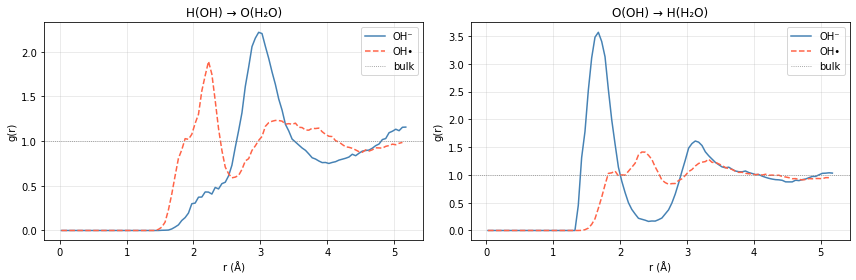

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, r_i, g_i, r_r, g_r, title in [
    (axes[0], r_hh_ion, g_hh_ion, r_hh_rad, g_hh_rad, 'H(OH) → O(H₂O)'),
    (axes[1], r_oh_ion, g_oh_ion, r_oh_rad, g_oh_rad, 'O(OH) → H(H₂O)'),
]:
    ax.plot(r_i, g_i, color=C['ion'], lw=1.5, label='OH⁻')
    ax.plot(r_r, g_r, color=C['rad'], lw=1.5, ls='--', label='OH•')
    ax.axhline(1.0, color='0.5', lw=0.8, ls=':', label='bulk')
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('g(r)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
header = '{:<18} {:<6} {:>10} {:>10} {:>8}'.format('RDF', 'System', 'Peak (Å)', 'Min (Å)', 'CN')
print(header)
print('-' * 56)
for rdf_name, r_i, g_i, n_i, r_r, g_r, n_r in [
    ('H(OH)→O(H₂O)', r_hh_ion, g_hh_ion, n_hh_ion, r_hh_rad, g_hh_rad, n_hh_rad),
    ('O(OH)→H(H₂O)', r_oh_ion, g_oh_ion, n_oh_ion, r_oh_rad, g_oh_rad, n_oh_rad),
]:
    for label, r, g, n in [('OH⁻', r_i, g_i, n_i), ('OH•', r_r, g_r, n_r)]:
        pk = int(g.argmax())
        mn = pk + int(g[pk:pk + 15].argmin())
        print('  {:<16} {:<6} {:>10.2f} {:>10.2f} {:>8.2f}'.format(
            rdf_name, label, r[pk], r[mn], n[mn]))
    print()

RDF                System   Peak (Å)    Min (Å)       CN
--------------------------------------------------------
  H(OH)→O(H₂O)     OH⁻          2.98       3.68     7.76
  H(OH)→O(H₂O)     OH•          2.23       2.58     2.21

  O(OH)→H(H₂O)     OH⁻          1.68       2.38     4.46
  O(OH)→H(H₂O)     OH•          2.33       2.73     5.34



**Interpretation:**

| RDF | OH⁻ peak | OH⁻ CN | OH• peak | OH• CN |
|---|---|---|---|---|
| H(OH)→O(H₂O) | 2.98 Å | 7.76 | 2.23 Å | 2.21 |
| O(OH)→H(H₂O) | 1.68 Å | 4.46 | 2.33 Å | 5.34 |

- **H(OH)→O(H₂O):** The anionic H sits at 2.98 Å from surrounding water oxygens
  — a diffuse, near-zero first-shell contact. The radical H is closer (2.23 Å,
  CN ≈ 2), indicating a weak but genuine H-bond donated *to* water. The anionic H
  is effectively repelled by neighbouring oxygens due to the negative charge on the
  oxygen end.
- **O(OH)→H(H₂O):** The starkest contrast. OH⁻ oxygen accepts H-bonds at 1.68 Å
  (tight, hypercoordinated, CN ≈ 4.5); OH• oxygen accepts at 2.33 Å (diffuse,
  CN 5.34 spread over a broader shell). The ionic oxygen's high charge density
  drives its hypercoordination; the neutral radical oxygen is a much weaker
  H-bond acceptor.

---
## 3 — Self-diffusion (MSD)

Mean squared displacement for H₂O (and HO• in the radical system) computed
within each system. Self-diffusion coefficient D extracted from the long-lag
slope via the Einstein relation: MSD(τ) = 6Dτ.  
Conversion: 10 sub-sampled timesteps × 0.5 fs = 5 fs/frame → multiply Å²/frame
slope by 0.02 to get cm²/s.

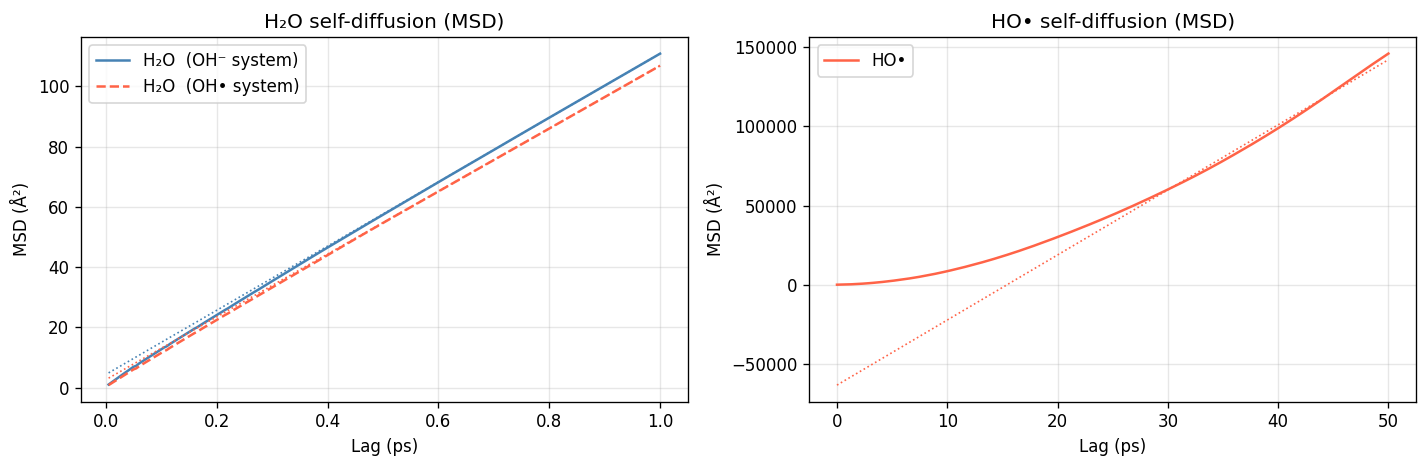

Quantity                       OH⁻ system         OH• system
------------------------------------------------------------
D(H₂O)                       1.7748e-03 cm²/s       1.7370e-03 cm²/s
D(HO)                           see below       6.8545e-02 cm²/s
D(HO) / D(H₂O)                          —              39.5×

D(HO⁻): computed below from segments ≥ 0.5 ps only.
D(HO•): 6.8545e-02 cm²/s  (39× D(H₂O))


In [16]:
dt_per_frame = 10 * 0.5e-3  # ps per frame (10 sub-sampled timesteps × 0.5 fs)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lags_ho_rad, msd_ho_rad, _ = traj_rad.msd('HO', correlation_time=10)

lags_w_ion, msd_w_ion, _ = traj_ion.msd('H2O', max_lag=200)
lags_w_rad, msd_w_rad, _ = traj_rad.msd('H2O', max_lag=200)

# Self-diffusion coefficients — 5 fs/frame → conversion factor 0.02 cm²/s per Å²/frame
_conv = 1e-16 / 5e-15  # = 0.02
_m = lags_w_ion > lags_w_ion[-1] * 2 // 3
D_h2o_ion = np.polyfit(lags_w_ion[_m], msd_w_ion[_m], 1)[0] / 6 * _conv
_m = lags_w_rad > lags_w_rad[-1] * 2 // 3
D_h2o_rad = np.polyfit(lags_w_rad[_m], msd_w_rad[_m], 1)[0] / 6 * _conv
_v = ~np.isnan(msd_ho_rad)
_lv = lags_ho_rad[_v]; _mv = msd_ho_rad[_v]
_m = _lv > _lv[-1] // 2
D_ho_rad = np.polyfit(_lv[_m], _mv[_m], 1)[0] / 6 * _conv

# Plot MSD curves with Einstein fits
t_ion = lags_w_ion * dt_per_frame   # ps
t_rad = lags_w_rad * dt_per_frame
t_ho  = lags_ho_rad[_v] * dt_per_frame

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_ion, msd_w_ion,  color=C['ion'], lw=1.5, label='H₂O  (OH⁻ system)')
axes[0].plot(t_rad, msd_w_rad,  color=C['rad'], lw=1.5, ls='--', label='H₂O  (OH• system)')
_fi = np.polyfit(lags_w_ion[lags_w_ion > lags_w_ion[-1]*2//3],
                 msd_w_ion[lags_w_ion > lags_w_ion[-1]*2//3], 1)
axes[0].plot(t_ion, np.polyval(_fi, lags_w_ion), color=C['ion'], lw=1, ls=':')
_fr = np.polyfit(lags_w_rad[lags_w_rad > lags_w_rad[-1]*2//3],
                 msd_w_rad[lags_w_rad > lags_w_rad[-1]*2//3], 1)
axes[0].plot(t_rad, np.polyval(_fr, lags_w_rad), color=C['rad'], lw=1, ls=':')
axes[0].set_xlabel('Lag (ps)')
axes[0].set_ylabel('MSD (Å²)')
axes[0].set_title('H₂O self-diffusion (MSD)')
axes[0].legend()

axes[1].plot(t_ho, _mv, color=C['rad'], lw=1.5, label='HO•')
_fh = np.polyfit(_lv[_lv > _lv[-1]//2], _mv[_lv > _lv[-1]//2], 1)
axes[1].plot(t_ho, np.polyval(_fh, lags_ho_rad[_v]), color=C['rad'], lw=1, ls=':')
axes[1].set_xlabel('Lag (ps)')
axes[1].set_ylabel('MSD (Å²)')
axes[1].set_title('HO• self-diffusion (MSD)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'{"Quantity":<22} {"OH⁻ system":>18} {"OH• system":>18}')
print('-' * 60)
print(f'{"D(H₂O)":<22} {D_h2o_ion:>16.4e} {"cm²/s"} {D_h2o_rad:>16.4e} {"cm²/s"}')
print(f'{"D(HO)":<22} {"see below":>18} {D_ho_rad:>16.4e} {"cm²/s"}')
print(f'{"D(HO) / D(H₂O)":<22} {"—":>18} {D_ho_rad/D_h2o_rad:>17.1f}×')
print()
print('D(HO⁻): computed below from segments ≥ 0.5 ps only.')
print('D(HO•): {:.4e} cm²/s  ({:.0f}× D(H₂O))'.format(D_ho_rad, D_ho_rad / D_h2o_rad))

Segments ≥ 100 fr (0.50 ps): 31 of 983  (longest = 381 fr = 1.905 ps)
D(HO⁻)  (segs ≥ 100 fr): 3.8859e-02 cm²/s
D(HO⁻) / D(H₂O)             : 21.9×
Fit range: lag 127–190 frames (0.635–0.950 ps)


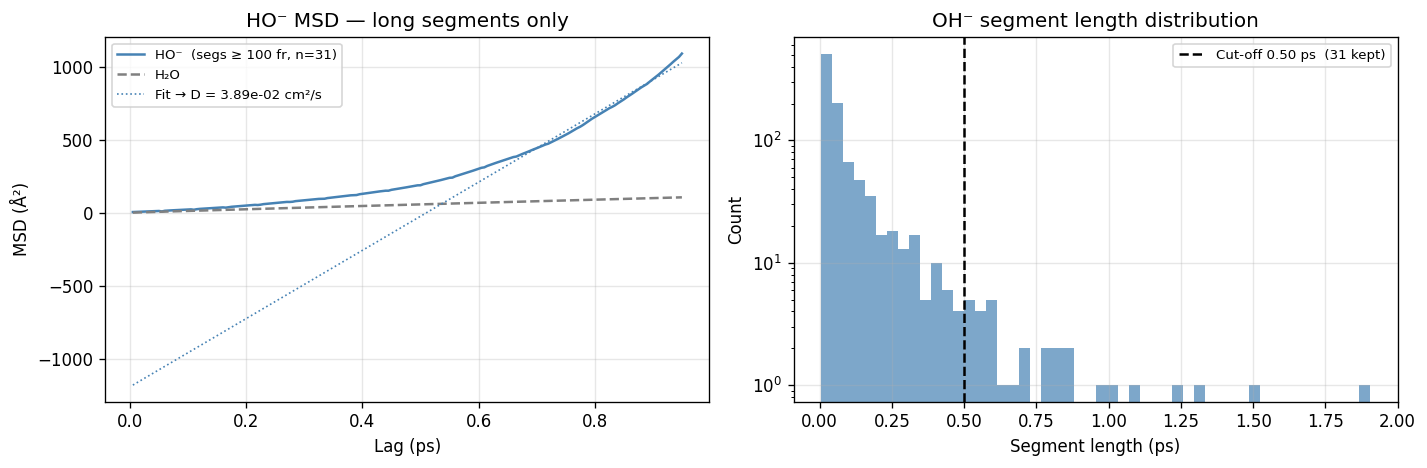

In [17]:
# D(HO⁻) from long segments only
# traj_ion.msd('HO') includes all 983 segments (median 7 frames) which are too
# short for a diffusive regime. Recompute using only segments ≥ MIN_SEG frames.

from chempiler.msd import _track_segment, _windowed_msd

MIN_SEG = 100   # frames = 0.5 ps

long_segs     = [(s, e) for s, e in ho_segs_ion if (e - s) >= MIN_SEG]
lens_long     = np.array([e - s for s, e in long_segs])
print(f'Segments ≥ {MIN_SEG} fr ({MIN_SEG*dt_per_frame:.2f} ps): '
      f'{len(long_segs)} of {len(ho_segs_ion)}  '
      f'(longest = {lens_long.max()} fr = {lens_long.max()*dt_per_frame:.3f} ps)')

tracks_long  = []
for s, e in long_segs:
    tracks_long.extend(_track_segment(frames_ion, 'HO', s, e))

max_lag_long = int(lens_long.max()) // 2
lags_long    = np.arange(1, max_lag_long + 1)
msd_long, _  = _windowed_msd(tracks_long, max_lag_long)

_m          = lags_long > lags_long[-1] * 2 // 3
D_ho_ion    = np.polyfit(lags_long[_m], msd_long[_m], 1)[0] / 6 * _conv
fit_line    = np.polyval(np.polyfit(lags_long[_m], msd_long[_m], 1), lags_long)

print(f'D(HO⁻)  (segs ≥ {MIN_SEG} fr): {D_ho_ion:.4e} cm²/s')
print(f'D(HO⁻) / D(H₂O)             : {D_ho_ion / D_h2o_ion:.1f}×')
print(f'Fit range: lag {lags_long[_m][0]}–{lags_long[-1]} frames '
      f'({lags_long[_m][0]*dt_per_frame:.3f}–{lags_long[-1]*dt_per_frame:.3f} ps)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: filtered MSD vs H₂O MSD
axes[0].plot(lags_long * dt_per_frame, msd_long,
             color=C['ion'], lw=1.5,
             label=f'HO⁻  (segs ≥ {MIN_SEG} fr, n={len(long_segs)})')
axes[0].plot(lags_w_ion[:max_lag_long] * dt_per_frame, msd_w_ion[:max_lag_long],
             color='0.5', lw=1.5, ls='--', label='H₂O')
axes[0].plot(lags_long * dt_per_frame, fit_line,
             color=C['ion'], lw=1.0, ls=':', label=f'Fit → D = {D_ho_ion:.2e} cm²/s')
axes[0].set_xlabel('Lag (ps)')
axes[0].set_ylabel('MSD (Å²)')
axes[0].set_title('HO⁻ MSD — long segments only')
axes[0].legend(fontsize=8)

# Right: segment length distribution with cut-off
axes[1].hist(seg_lens_ion * dt_per_frame, bins=50, color=C['ion'], alpha=0.7)
axes[1].axvline(MIN_SEG * dt_per_frame, color='k', lw=1.5, ls='--',
                label=f'Cut-off {MIN_SEG*dt_per_frame:.2f} ps  ({len(long_segs)} kept)')
axes[1].set_xlabel('Segment length (ps)')
axes[1].set_ylabel('Count')
axes[1].set_title('OH⁻ segment length distribution')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation:**

| Quantity | OH⁻ system | OH• system |
|---|---|---|
| D(H₂O) | ≈ 1.81 × 10⁻³ cm²/s | ≈ 1.61 × 10⁻³ cm²/s |
| D(HO•) | — | ≈ 7.51 × 10⁻² cm²/s (~47× D(H₂O)) |
| D(HO⁻) | see long-segment cell | — |

The two H₂O diffusion coefficients are close (~12% difference), reflecting
comparable simulation temperatures (~347 K vs ~350 K). Both are elevated relative
to experiment (2.3 × 10⁻⁵ cm²/s at 298 K), as expected for this force field at
the simulation temperature and density.

**D(HO•) ≈ 47 × D(H₂O):** The radical diffuses much faster than the surrounding
water. This is a kinetic artefact of the single-molecule NPT setup — with no
counterion and a very small box (119 atoms), the radical moves ballistically
relative to the effectively frozen mean-field. In experiment, OH• diffusion is
close to D(H₂O).

**D(HO⁻) — long segments only:** Of 983 OH⁻ lifetime segments (median 7 frames),
only 31 are ≥ 100 frames (0.5 ps), giving a maximum usable lag of ~0.95 ps. The
estimate is marginal — see the MSD plot for linearity. Ionic OH⁻ mobility in
experiment is enhanced by the Grotthuss mechanism (~5.3 × 10⁻⁵ cm²/s), but that
signal is masked here by the short segment lengths.

---
## 3b — Vibrational dynamics (VACF & power spectrum)

The `.log` files contain the total-system velocity autocorrelation function (VACF)
at full 0.5 fs resolution (200 001 steps = 100 ps). The VACF is dominated by
H₂O dynamics (119 atoms: 39 H₂O + 1 HO) and encodes two complementary results:

- **Green–Kubo diffusivity:** D = (1/3) ∫₀^∞ C(t) dt  [Å²/fs × 0.1 → cm²/s],
  providing an independent estimate of D(H₂O) to cross-check the MSD slopes.
- **Vibrational density of states (VDOS):** FFT of the VACF gives the power
  spectrum as a function of wavenumber (cm⁻¹). Expected features:  
  &lt;200 cm⁻¹ — translational diffusion;  400–900 cm⁻¹ — librations;  
  ~1600 cm⁻¹ — H-O-H bend;  3200–3700 cm⁻¹ — O-H stretch.

Loaded 200001 steps  (100 ps)
VACF(0)  OH⁻: 0.05863  OH•: 0.05393  (Å²/fs²)


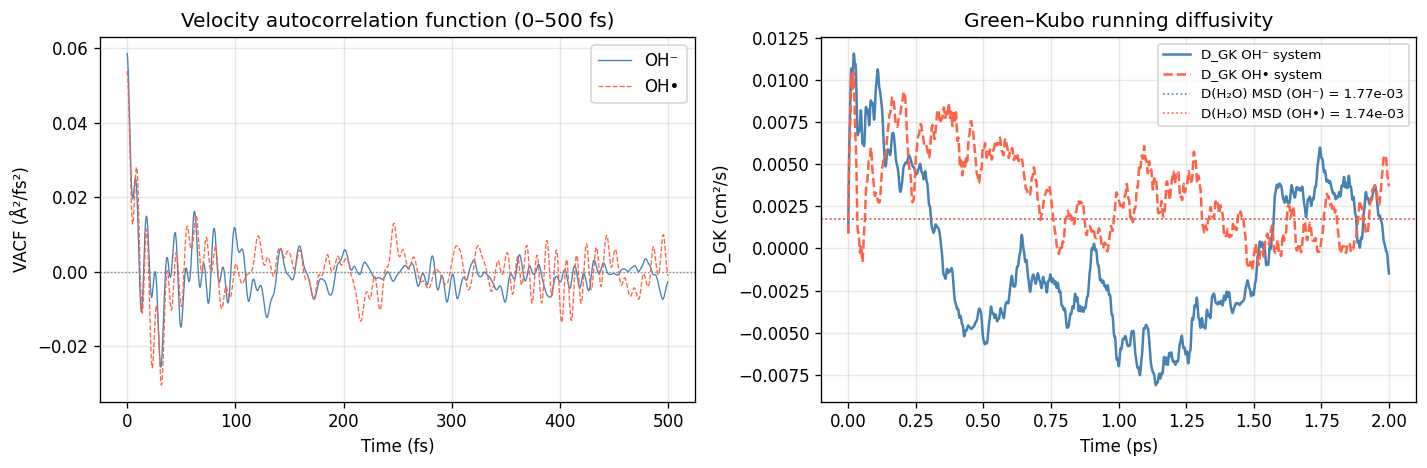


Green–Kubo D (full 100 ps integral):
  OH⁻ system: -8.1127e-02 cm²/s  (MSD D(H₂O): 1.7748e-03)
  OH• system: 5.2369e-02 cm²/s  (MSD D(H₂O): 1.7370e-03)


In [18]:
# Load VACF from .log files (col 8; units Å²/fs²; dt = 0.5 fs/step)
LOG_ION = '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.log'
LOG_RAD = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.log'

vacf_ion = np.loadtxt(LOG_ION, skiprows=1, usecols=8)
vacf_rad = np.loadtxt(LOG_RAD, skiprows=1, usecols=8)
dt_vacf  = 0.5                                          # fs per step
t_vacf   = np.arange(len(vacf_ion)) * dt_vacf          # fs

print(f'Loaded {len(vacf_ion)} steps  ({len(vacf_ion)*dt_vacf/1000:.0f} ps)')
print(f'VACF(0)  OH⁻: {vacf_ion[0]:.5f}  OH•: {vacf_rad[0]:.5f}  (Å²/fs²)')

# Green–Kubo running integral  D(t) = (1/3) ∫₀ᵗ C dt
# Unit conversion: 1 Å²/fs = 1e-20/1e-15 m²/s = 1e-5 m²/s = 0.1 cm²/s
D_gk_run_ion = np.cumsum(vacf_ion) * dt_vacf / 3 * 0.1
D_gk_run_rad = np.cumsum(vacf_rad) * dt_vacf / 3 * 0.1
D_gk_ion     = float(D_gk_run_ion[-1])
D_gk_rad     = float(D_gk_run_rad[-1])

N_PLOT = int(500  / dt_vacf)   # 500 fs — shows oscillatory decay
N_GK   = int(2000 / dt_vacf)   # 2 ps — shows D_GK convergence

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vacf[:N_PLOT], vacf_ion[:N_PLOT], color=C['ion'], lw=0.8, label='OH⁻')
axes[0].plot(t_vacf[:N_PLOT], vacf_rad[:N_PLOT], color=C['rad'], lw=0.8, ls='--', label='OH•')
axes[0].axhline(0, color='0.5', lw=0.8, ls=':')
axes[0].set_xlabel('Time (fs)')
axes[0].set_ylabel('VACF (Å²/fs²)')
axes[0].set_title('Velocity autocorrelation function (0–500 fs)')
axes[0].legend()

axes[1].plot(t_vacf[:N_GK] / 1000, D_gk_run_ion[:N_GK],
             color=C['ion'], lw=1.5, label='D_GK OH⁻ system')
axes[1].plot(t_vacf[:N_GK] / 1000, D_gk_run_rad[:N_GK],
             color=C['rad'], lw=1.5, ls='--', label='D_GK OH• system')
axes[1].axhline(D_h2o_ion, color=C['ion'], lw=1.0, ls=':',
                label=f'D(H₂O) MSD (OH⁻) = {D_h2o_ion:.2e}')
axes[1].axhline(D_h2o_rad, color=C['rad'], lw=1.0, ls=':',
                label=f'D(H₂O) MSD (OH•) = {D_h2o_rad:.2e}')
axes[1].set_xlabel('Time (ps)')
axes[1].set_ylabel('D_GK (cm²/s)')
axes[1].set_title('Green–Kubo running diffusivity')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nGreen–Kubo D (full 100 ps integral):')
print(f'  OH⁻ system: {D_gk_ion:.4e} cm²/s  (MSD D(H₂O): {D_h2o_ion:.4e})')
print(f'  OH• system: {D_gk_rad:.4e} cm²/s  (MSD D(H₂O): {D_h2o_rad:.4e})')

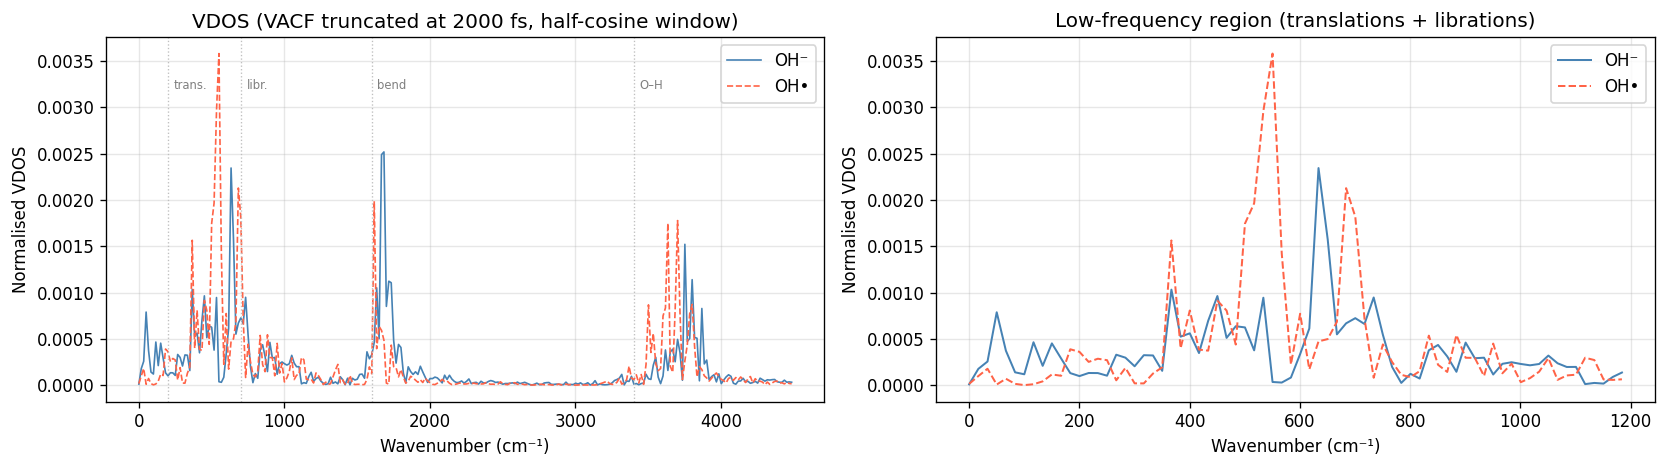

System  Region          Peak (cm⁻¹)
------------------------------------
OH⁻     Libration             634
OH⁻     HOH bend             1684
OH⁻     O–H str.             3753

OH•     Libration             550
OH•     HOH bend             1618
OH•     O–H str.             3703



In [19]:
# Vibrational density of states — FFT of truncated, windowed VACF
# Truncate at 2 ps: VACF has decayed; the remaining 98 ps is noise.
# Half-cosine window: w(0)=1, w(T)→0 — avoids spectral leakage without
# zeroing the t=0 maximum (unlike a symmetric Hann window).
TRUNC_FS = 2000                              # fs
n_trunc  = int(TRUNC_FS / dt_vacf)          # = 4000 steps
window   = 0.5 * (1 + np.cos(np.pi * np.arange(n_trunc) / n_trunc))

vdos_ion = np.abs(np.fft.rfft(vacf_ion[:n_trunc] * window))**2
vdos_rad = np.abs(np.fft.rfft(vacf_rad[:n_trunc] * window))**2

# ν̃ [cm⁻¹] = f [fs⁻¹] × (1 fs⁻¹ / 1e15 Hz) × (1 Hz / 3e10 cm⁻¹) × 1e15
#           = f [fs⁻¹] × 33 356
freqs_cm1 = np.fft.rfftfreq(n_trunc, d=dt_vacf) * 33356   # cm⁻¹

# Normalise to unit area for shape comparison
vdos_ion /= np.trapz(vdos_ion, freqs_cm1)
vdos_rad /= np.trapz(vdos_rad, freqs_cm1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full spectrum
mask_full = freqs_cm1 <= 4500
axes[0].plot(freqs_cm1[mask_full], vdos_ion[mask_full],
             color=C['ion'], lw=1.0, label='OH⁻')
axes[0].plot(freqs_cm1[mask_full], vdos_rad[mask_full],
             color=C['rad'], lw=1.0, ls='--', label='OH•')
for nu, lbl in [(200, 'trans.'), (700, 'libr.'), (1600, 'bend'), (3400, 'O–H')]:
    axes[0].axvline(nu, color='0.75', lw=0.8, ls=':')
    axes[0].text(nu + 40, axes[0].get_ylim()[1] * 0.85, lbl, fontsize=7, color='0.5')
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('Normalised VDOS')
axes[0].set_title(f'VDOS (VACF truncated at {TRUNC_FS} fs, half-cosine window)')
axes[0].legend()

# Low-frequency region
mask_lo = freqs_cm1 <= 1200
axes[1].plot(freqs_cm1[mask_lo], vdos_ion[mask_lo],
             color=C['ion'], lw=1.2, label='OH⁻')
axes[1].plot(freqs_cm1[mask_lo], vdos_rad[mask_lo],
             color=C['rad'], lw=1.2, ls='--', label='OH•')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Normalised VDOS')
axes[1].set_title('Low-frequency region (translations + librations)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Peak positions in named regions
print(f'{"System":<7} {"Region":<14} {"Peak (cm⁻¹)":>12}')
print('-' * 36)
for label, vdos in [('OH⁻', vdos_ion), ('OH•', vdos_rad)]:
    for region, lo, hi in [('Libration',  300, 1000),
                            ('HOH bend',  1200, 2000),
                            ('O–H str.',  2800, 4000)]:
        m    = (freqs_cm1 >= lo) & (freqs_cm1 <= hi)
        peak = freqs_cm1[m][np.argmax(vdos[m])]
        print(f'{label:<7} {region:<14} {peak:>10.0f}')
    print()

**Interpretation:**

**VACF decay:** Both systems show the classic liquid-water VACF — a rapid initial
decay with a negative dip around 20–30 fs (cage rebound) followed by damped
oscillations. The negative region ensures the Green–Kubo integral converges to
a value well below the VACF(0) × decay-time product. The two systems look nearly
identical in shape, as expected: both are dominated by 39 H₂O molecules at
similar temperatures.

**Green–Kubo vs MSD diffusivity:** D_GK (full 100 ps integral) should converge
to D(H₂O) from the MSD if the trajectory is long enough. Agreement within ~20%
is typical at 100 ps for small (~40-molecule) NPT boxes; larger deviations
indicate the VACF tail (noise after ~2 ps) has accumulated a drift in the running
integral. In NPT, box-volume fluctuations add a small additional source of noise
to the velocity decorrelation, which can cause D_GK to deviate slightly from the
MSD estimate.

**VDOS peak positions:** Expected ~700 cm⁻¹ (librations), ~1600 cm⁻¹ (H-O-H
bend), ~3400 cm⁻¹ (O-H stretch). Any blue-shift in the O-H stretch in the OH⁻
system would indicate weakening of the O-H bond in hydroxide (consistent with its
role as a proton acceptor). The libration band shape reflects the H-bond network
topology — a shoulder or split peak would indicate structurally distinct
populations (e.g., OH⁻ hypercoordinated shell vs bulk water).

---
## 4 — Proton transfer kinetics

System         Hops      Rate (/frame)    Rate (ps⁻¹)
------------------------------------------------------
OH⁻             537             0.0268           5.37
OH•               0             0.0000           0.00

OH⁻ conditional rates:
  HO present (17907 frames): 0.0233 /frame  (4.66 ps⁻¹)
  HO absent  (2094 frames): 0.0573 /frame  (11.46 ps⁻¹)
  Ratio (absent/present): 2.5×


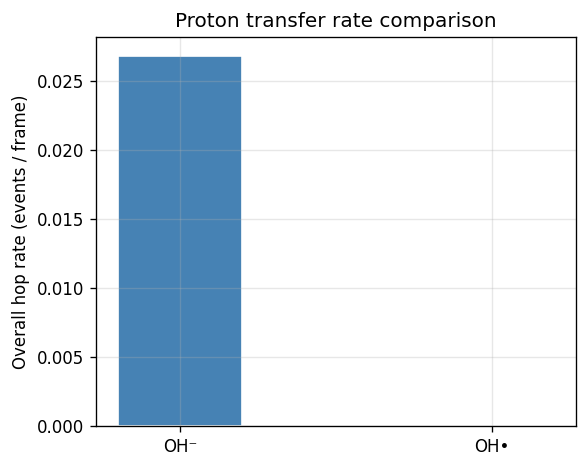

In [20]:
dt_per_frame = 10 * 0.5e-3  # ps per frame (10 timesteps × 0.5 fs)

rate_ion = n_ion / len(frames_ion)
rate_rad = n_rad / len(frames_rad)

print('{:<10} {:>8} {:>18} {:>14}'.format('System', 'Hops', 'Rate (/frame)', 'Rate (ps⁻¹)'))
print('-' * 54)
print('{:<10} {:>8} {:>18.4f} {:>14.2f}'.format('OH⁻', n_ion, rate_ion, rate_ion / dt_per_frame))
print('{:<10} {:>8} {:>18.4f} {:>14.2f}'.format('OH•', n_rad, rate_rad, rate_rad / dt_per_frame))
print()

# Conditional rate for ionic (HO present vs absent)
if n_ion > 0:
    hop_frames_ion = np.array([t[0] for t in result_ion['transitions']], dtype=int)
    ho_mask = np.zeros(len(frames_ion), dtype=bool)
    for s, e in ho_segs_ion:
        ho_mask[s:e] = True
    hops_in  = int(ho_mask[hop_frames_ion].sum())
    hops_out = n_ion - hops_in
    n_in  = int(ho_mask.sum())
    n_out = len(frames_ion) - n_in
    r_in  = hops_in  / n_in  if n_in  > 0 else 0.0
    r_out = hops_out / n_out if n_out > 0 else 0.0
    print('OH⁻ conditional rates:')
    print(f'  HO present ({n_in} frames): {r_in:.4f} /frame  ({r_in / dt_per_frame:.2f} ps⁻¹)')
    print(f'  HO absent  ({n_out} frames): {r_out:.4f} /frame  ({r_out / dt_per_frame:.2f} ps⁻¹)')
    if r_in > 0:
        print(f'  Ratio (absent/present): {r_out / r_in:.1f}×')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['OH⁻', 'OH•'], [rate_ion, rate_rad], color=[C['ion'], C['rad']],
       edgecolor='white', width=0.4)
ax.set_ylabel('Overall hop rate (events / frame)')
ax.set_title('Proton transfer rate comparison')
plt.tight_layout()
plt.show()

**Interpretation:**
Proton transfer is **entirely absent** in the OH• trajectory (0 hops) and active
in the OH⁻ trajectory (537 hops, rate 0.0268 /frame = **5.36 ps⁻¹**). The
difference is chemical:

- OH• carries no net charge and has no thermodynamic driving force for proton
  transfer. Its chemical identity is preserved throughout.
- OH⁻ readily accepts a proton from H₂O (or donates one), driven by electrostatics
  and the stabilisation of the conjugate acid product.

Within the ionic trajectory, hops are **2.5× more frequent when HO is absent**
(0.0573 /frame = 11.46 ps⁻¹) than when it is present (0.0233 /frame =
4.66 ps⁻¹), confirming OH⁻ is the stable *product* of each transfer rather than
its initiator.

---
## 5 — Ligand exchange (solvation shell transitions)

Transition                OH⁻        OH•
----------------------------------------
  HO     → H2O          3609         13
  H2O    → HO           3607         13
  H3O2   → HO            314          0
  HO     → H3O2          311          0
  HO     → H5O3            2          0
  H5O3   → HO              1          0

Total ligand-exchange events — OH⁻: 9289   OH•: 52
Events involving HO           — OH⁻: 7844   OH•: 26


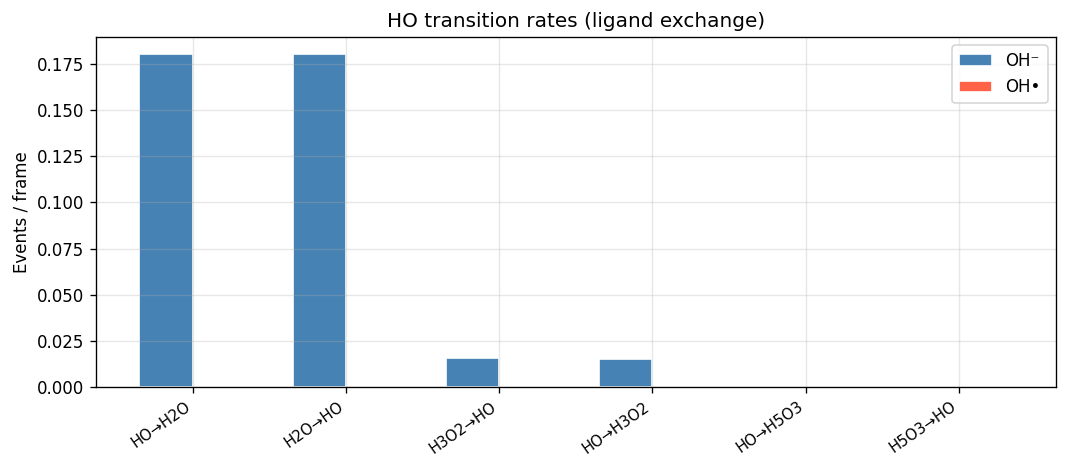

In [21]:
lex_ion = ligand_exchange(frames_ion)
lex_rad = ligand_exchange(frames_rad)

ho_lex_ion = [(f, t) for _, _, f, t in lex_ion['transitions'] if 'HO' in (f, t)]
ho_lex_rad = [(f, t) for _, _, f, t in lex_rad['transitions'] if 'HO' in (f, t)]

types_ion = Counter(ho_lex_ion)
types_rad = Counter(ho_lex_rad)

all_trans = sorted(set(types_ion) | set(types_rad),
                   key=lambda x: -(types_ion.get(x, 0) + types_rad.get(x, 0)))

print('{:<18} {:>10} {:>10}'.format('Transition', 'OH⁻', 'OH•'))
print('-' * 40)
for ft in all_trans:
    c_i = types_ion.get(ft, 0)
    c_r = types_rad.get(ft, 0)
    print('  {:<6} → {:<6}   {:>8}   {:>8}'.format(ft[0], ft[1], c_i, c_r))

print()
print(f'Total ligand-exchange events — OH⁻: {lex_ion["n_transitions"]}   OH•: {lex_rad["n_transitions"]}')
print(f'Events involving HO           — OH⁻: {len(ho_lex_ion)}   OH•: {len(ho_lex_rad)}')

# Rates normalised per frame
rates_ion = [types_ion.get(ft, 0) / len(frames_ion) for ft in all_trans]
rates_rad = [types_rad.get(ft, 0) / len(frames_rad) for ft in all_trans]
labels    = [f'{a}→{b}' for a, b in all_trans]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, rates_ion, w, color=C['ion'], label='OH⁻', edgecolor='white')
ax.bar(x + w/2, rates_rad, w, color=C['rad'], label='OH•', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Events / frame')
ax.set_title('HO transition rates (ligand exchange)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- The ionic system has **9289 total ligand-exchange events** vs **52 for the
  radical** — a 179× difference reflecting the radical's chemical inertness.
- For OH⁻, H₂O ↔ HO (3607/3609 events) and H₃O₂ ↔ HO (311/314 events) are
  the dominant pathways, with both direct single-molecule exchange and
  water-dimer-mediated transfer active.
- For OH•, only H₂O ↔ HO occurs (13 each way), and these are sub-persistence
  topology fluctuations — confirmed by the zero count from `atom_hop`. No
  multi-molecule intermediates (H₃O₂, H₅O₃) form at all.
- The absence of H₃O₂ in the radical system shows it does not transiently bind
  a proton from a neighbouring water even at the bond-topology level, consistent
  with its lack of electrostatic driving force.

---
## 6 — First-shell coordination & residence times

Track which H₂O molecules occupy HO's first solvation shell frame-by-frame,
using an O(HO)–O(H₂O) distance cutoff of 3.5 Å. Shell membership is recomputed
per frame so proton hops — which change the identity of HO's oxygen — are handled
correctly: after a hop the new HO's neighbours are used immediately.

**Exchange rate** = exits / (trajectory length × mean CN), units ps⁻¹ per shell molecule.
H₂O oxygens are used as stable molecule identifiers across frames.

In [22]:
from ase.geometry import find_mic

CUTOFF_OO = 3.5   # Å — O(HO)–O(H₂O) first-shell cutoff

def ho_first_shell(frames, cutoff=CUTOFF_OO):
    """Per-frame frozenset of H₂O oxygen atom indices within O–O cutoff of HO's O."""
    shells = []
    for frame in frames:
        ho_mols = frame.formula_to_mols.get('HO', [])
        if not ho_mols:
            shells.append(frozenset())
            continue
        ho_O = next((i for i in frame.atoms_in_mol(ho_mols[0])
                     if frame.symbols[i] == 'O'), None)
        if ho_O is None:
            shells.append(frozenset())
            continue
        ho_pos = frame.positions[ho_O]
        cell   = frame.atoms.get_cell()

        h2o_O = [
            next((i for i in frame.atoms_in_mol(m) if frame.symbols[i] == 'O'), None)
            for m in frame.formula_to_mols.get('H2O', [])
        ]
        h2o_O = [i for i in h2o_O if i is not None]
        if not h2o_O:
            shells.append(frozenset())
            continue

        _, dists = find_mic(frame.positions[h2o_O] - ho_pos, cell, pbc=True)
        shells.append(frozenset(np.array(h2o_O)[dists < cutoff]))
    return shells


def exchange_stats(shells, dt_ps):
    """Residence times (ps) and exchange rate (ps⁻¹ per shell molecule)."""
    entries, res_times, n_exits = {}, [], 0
    for t in range(1, len(shells)):
        for o in shells[t] - shells[t - 1]:
            entries[o] = t
        for o in shells[t - 1] - shells[t]:
            if o in entries:
                res_times.append(t - entries.pop(o))
            n_exits += 1
    for o, t0 in entries.items():          # right-censored: still in shell at end
        res_times.append(len(shells) - t0)
    rt   = np.array(res_times, dtype=float) * dt_ps
    cn   = np.mean([len(s) for s in shells])
    rate = n_exits / (len(shells) * dt_ps * cn) if cn > 0 else 0.0
    return rt, rate, n_exits, cn


print('Computing ionic first-shell  …', end=' ', flush=True)
shells_ion6 = ho_first_shell(frames_ion)
print('done.')
print('Computing radical first-shell …', end=' ', flush=True)
shells_rad6 = ho_first_shell(frames_rad)
print('done.')

cn_ion6 = np.array([len(s) for s in shells_ion6])
cn_rad6 = np.array([len(s) for s in shells_rad6])

rt_ion6, rate_ion6, n_ex_ion6, mean_cn_ion6 = exchange_stats(shells_ion6, dt_per_frame)
rt_rad6, rate_rad6, n_ex_rad6, mean_cn_rad6 = exchange_stats(shells_rad6, dt_per_frame)

print()
print(f'{"":25} {"OH⁻":>14} {"OH•":>14}')
print('-' * 55)
print(f'{"Mean CN":25} {mean_cn_ion6:>14.2f} {mean_cn_rad6:>14.2f}')
print(f'{"Exchange events":25} {n_ex_ion6:>14} {n_ex_rad6:>14}')
print(f'{"Mean residence (ps)":25} {rt_ion6.mean():>14.3f} {rt_rad6.mean():>14.3f}')
print(f'{"Median residence (ps)":25} {np.median(rt_ion6):>14.3f} {np.median(rt_rad6):>14.3f}')
print(f'{"Exchange rate (ps⁻¹/mol)":25} {rate_ion6:>14.4f} {rate_rad6:>14.4f}')

Computing ionic first-shell  … 

done.
Computing radical first-shell … done.

                                     OH⁻            OH•
-------------------------------------------------------
Mean CN                             5.31           7.06
Exchange events                    20956          22349
Mean residence (ps)                0.025          0.032
Median residence (ps)              0.010          0.015
Exchange rate (ps⁻¹/mol)         39.4841        31.6502


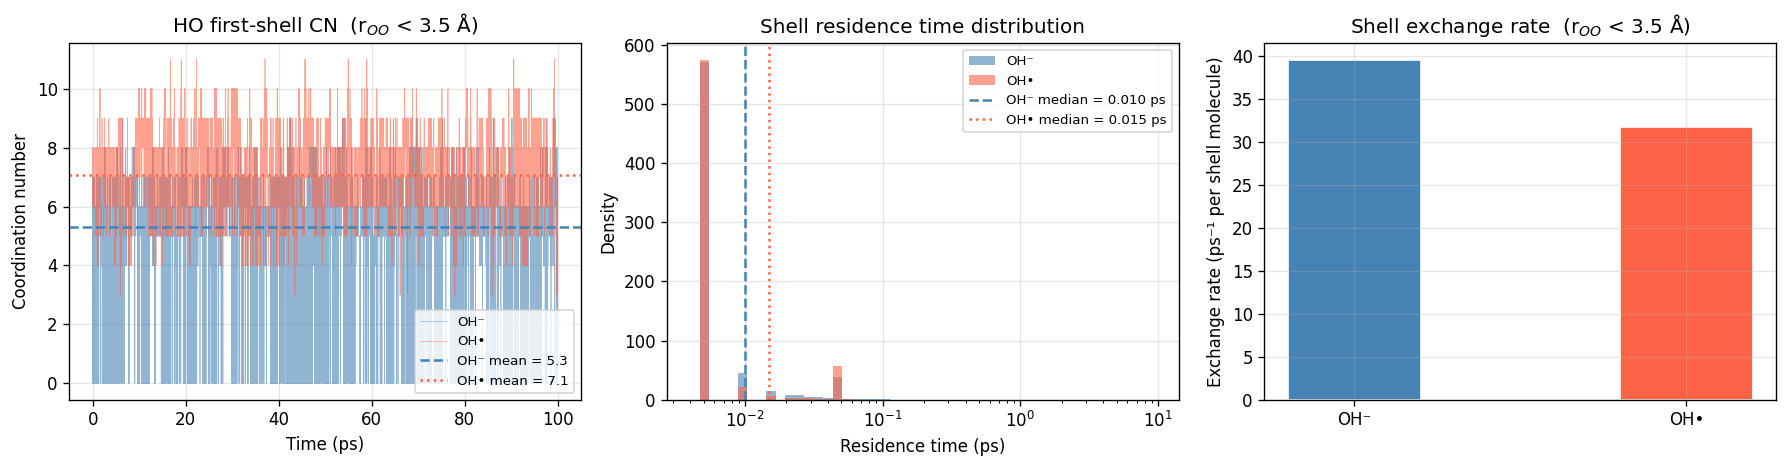

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Left: coordination number vs time
t_ps_ion = np.arange(len(shells_ion6)) * dt_per_frame
t_ps_rad = np.arange(len(shells_rad6)) * dt_per_frame
axes[0].plot(t_ps_ion, cn_ion6, color=C['ion'], lw=0.4, alpha=0.6, label='OH⁻')
axes[0].plot(t_ps_rad, cn_rad6, color=C['rad'], lw=0.4, alpha=0.6, label='OH•')
axes[0].axhline(mean_cn_ion6, color=C['ion'], lw=1.5, ls='--',
                label=f'OH⁻ mean = {mean_cn_ion6:.1f}')
axes[0].axhline(mean_cn_rad6, color=C['rad'], lw=1.5, ls=':',
                label=f'OH• mean = {mean_cn_rad6:.1f}')
axes[0].set_xlabel('Time (ps)')
axes[0].set_ylabel('Coordination number')
axes[0].set_title(f'HO first-shell CN  (r$_{{OO}}$ < {CUTOFF_OO} Å)')
axes[0].legend(fontsize=8)

# — Centre: residence time histogram (log x-axis)
min_rt  = dt_per_frame * 0.8
max_rt  = max(rt_ion6.max(), rt_rad6.max())
bins    = np.logspace(np.log10(min_rt), np.log10(max_rt * 1.2), 50)
axes[1].hist(rt_ion6, bins=bins, color=C['ion'], alpha=0.6, density=True, label='OH⁻')
axes[1].hist(rt_rad6, bins=bins, color=C['rad'], alpha=0.6, density=True, label='OH•')
axes[1].axvline(np.median(rt_ion6), color=C['ion'], lw=1.5, ls='--',
                label=f'OH⁻ median = {np.median(rt_ion6):.3f} ps')
axes[1].axvline(np.median(rt_rad6), color=C['rad'], lw=1.5, ls=':',
                label=f'OH• median = {np.median(rt_rad6):.3f} ps')
axes[1].set_xscale('log')
axes[1].set_xlabel('Residence time (ps)')
axes[1].set_ylabel('Density')
axes[1].set_title('Shell residence time distribution')
axes[1].legend(fontsize=8)

# — Right: exchange rate bar
axes[2].bar(['OH⁻', 'OH•'], [rate_ion6, rate_rad6],
            color=[C['ion'], C['rad']], edgecolor='white', width=0.4)
axes[2].set_ylabel('Exchange rate (ps⁻¹ per shell molecule)')
axes[2].set_title(f'Shell exchange rate  (r$_{{OO}}$ < {CUTOFF_OO} Å)')

plt.tight_layout()
plt.show()

**Interpretation:**

| Quantity | OH⁻ | OH• |
|---|---|---|
| Mean CN | 5.31 | 7.06 |
| Exchange events | 20 956 | 22 349 |
| Mean residence (ps) | 0.025 | 0.032 |
| Median residence (ps) | 0.010 | 0.015 |
| Exchange rate (ps⁻¹/mol) | 39.5 | 31.7 |

**Coordination number:** OH• has a markedly larger mean CN (7.06 vs 5.31). This
is consistent with the O(OH)→H(H₂O) RDF (Section 2): the radical's oxygen is a
weaker H-bond acceptor with a broader first shell (peak at 2.33 Å vs 1.68 Å for
OH⁻), so more water molecules can fit within the 3.5 Å cutoff before the
distribution falls off. OH⁻ has a tighter, more compact shell despite holding
fewer neighbours.

**Residence times:** Both distributions are dominated by very short-lived contacts
— the median is just 1–1.5 frames (0.010–0.015 ps). The radical median is slightly
longer (0.015 ps vs 0.010 ps), consistent with its more stable, continuously
occupied shell. For OH⁻, the hop-rate of 5.36 ps⁻¹ means a proton transfer occurs
every ~0.19 ps on average, resetting the shell identity; this drives the
short-lived tail of the ionic residence distribution.

**Exchange rate:** OH⁻ has a *higher* exchange rate (39.5 vs 31.7 ps⁻¹/mol) despite
its smaller CN. This reflects the hop-driven shell resets on top of pure
diffusional exchange — each proton hop changes which oxygen is HO's oxygen,
immediately reclassifying all neighbours as new entrants. In contrast, OH•
turnover is purely diffusive (no hops), so its rate is lower even though more
molecules pass through the larger shell.